# Clustering Homework Assignment

Your Name: ...  
Date: ...



# Problem: Clustering Automobile Customers

In this problem, we will explore how clustering can be used to help businesses learn more about their customers. We will use the dataset `autoSurvey_2025.csv`, which contains data from a customer survey conducted by a German automobile manufacturer. Survey respondents were customers who had purchased a vehicle from this manufacturer within the previous 3 months, and these customers were asked to rate several different aspects of their purchased automobile as either “important” (1) or “not important” (0). Each observation (row) corresponds to a customer. This dataset contains 793 rows (customers) and 13 columns (variables). There are also two features regarding the demographics of the customer. The variables in the dataset are described in Table 1.

| Variable | Description | 0 | 1 |
|------------------|------------------|------------------|------------------|
| `driving_properties` | General driving properties | not important | important |
| `interior` | Interior design and aesthetics | not important | important |
| `technology` | Technological features | not important | important |
| `comfort` | Comfort of seats and interior | not important | important |
| `reliability` | Reliability and dependability | not important | important |
| `handling` | Handling and maneuverability | not important | important |
| `power` | Power and performance of the engine | not important | important |
| `consumption` | Fuel consumption, i.e. miles per gallon | not important | important |
| `sporty` | Sports feeling (i.e., sports utility vehicle SUV) | not important | important |
| `safety` | Safety features | not important | important |
| `space` | Amount of space | not important | important |
| `gender` | Gender of the customer | male | female |
| `household` | Size of the customer’s household | 1-2 people | at least 3 people |

**Table 1**: Variables in the Automobile Customer Dataset

## (a) Exploratory Analysis

Let's start with some exploratory analysis of the dataset. Let's load the necessary libraries and the dataset.

In [3]:
# # ============================================================
# # Reading CSV Files in Google Colab
# # ============================================================

# # --- Option 1: Simple upload (requires uploading each time you reopen Colab) ---
# # from google.colab import files
# # uploaded = files.upload()  # Choose your CSV file manually

# # --- Option 2: Mount Google Drive  ---
# from google.colab import drive
# import os

# # Step 1 - Upload your data files to the same folder as this notebook in Google Drive.

# # Step 2 - Mount Google Drive (authorize when prompted)
# drive.mount('/content/drive')

# # Step 3 - Set your working directory
# # To find your own path:
# #   Option A: Run this to explore your Drive
# #       !ls "/content/drive/MyDrive/"

# # Example: replace the path below with the folder where your notebook is saved
# os.chdir("/content/drive/MyDrive/Colab Notebooks/ra/homework/Assignment 7")

# # Step 4 - Confirm that you’re in the correct directory
# print("Current directory:", os.getcwd())

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

auto = pd.read_csv("autoSurvey_2025.csv", index_col=0)

# Preview data
auto.head()

,driving_properties,interior,technology,comfort,reliability,handling,power,consumption,sporty,safety,space,gender,household
0,0,0,1,0,1,0,0,0,1,1,0,0,1
1,1,0,0,0,0,1,0,0,0,1,0,0,1
2,1,0,0,1,0,0,1,0,1,1,0,0,1
3,0,1,0,1,1,0,0,0,1,1,0,0,0
4,0,1,1,1,0,0,0,0,0,0,0,0,0


To get a better understanding of the data, let's calculate the means of each column in the entire dataset using the `mean` function.


In [5]:
# Compute column-wise means and sort in descending order
var_means = auto.mean(numeric_only=True).sort_values(ascending=False)

# Display as a DataFrame for clarity
var_means_df = pd.DataFrame(var_means, columns=["Variable Means"])
var_means_df

,Variable Means
driving_properties,0.689786
household,0.591425
power,0.489281
technology,0.438840
reliability,0.409836
sporty,0.407314
safety,0.399748
comfort,0.388398
handling,0.291299
consumption,0.255990


**Question 1.** Using the output above, what are the three most important features and three least important features to the survey respondents. Comment on the general demographics (gender/household) of the surveyed customers.


**Answer 1.**
*The three most important features seem to be* driving_properties, power and technology. The three least important ones are consumption, interior and space. Most of the customer are male (around 94%), and around 60% of the customers live in a household of at least 3 people.


Let's investigate whether there are any significant differences between male and female respondents, as well as household size.

In [6]:
# Average importance score for each feature, grouped by gender
gender_means = auto.groupby("gender").mean().T
gender_means

gender,0,1
driving_properties,0.698925,0.551020
interior,0.252688,0.142857
technology,0.446237,0.326531
comfort,0.385753,0.428571
reliability,0.408602,0.428571
handling,0.291667,0.285714
power,0.494624,0.408163
consumption,0.264785,0.122449
sporty,0.411290,0.346939
safety,0.392473,0.510204


In [7]:
household_means = auto.groupby("household").mean().T
household_means

household,0,1
driving_properties,0.666667,0.705757
interior,0.240741,0.249467
technology,0.429012,0.445629
comfort,0.391975,0.385928
reliability,0.459877,0.375267
handling,0.274691,0.302772
power,0.515432,0.471215
consumption,0.237654,0.268657
sporty,0.395062,0.415778
safety,0.413580,0.390192


**Question 2.** Comment on whether there are any significant differences in automobile preferences across the two dimensions above (gender and household size).

**Answer 2.** Male customers seem to value more the driving_properties, interior, technology, handling, power, consumption, sporty, and space features. The female customers on the contrary give more importance to the comfort, reliability, and safety features. The major differences seem to occur mainly for the **driving** **properties**, **interior**, **technology**, **consumption**, **safety** and **space** features.

Let's continue by computing the correlation matrix of the dataset.

In Python, this can be done using the `DataFrame.corr()` function from pandas, which calculates pairwise correlation coefficients between all numeric columns.

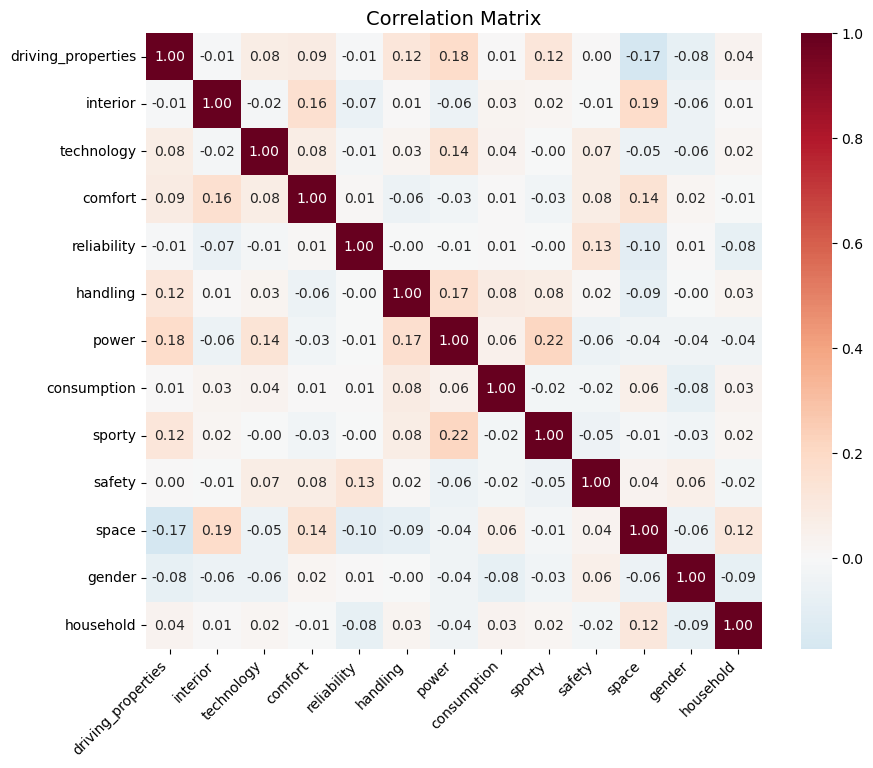

In [8]:
# Compute correlation matrix using pandas
corr_matrix = auto.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(
    corr_matrix,
    cmap="RdBu_r",
    center=0,
    annot=True,
    fmt=".2f",
    square=True
)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.title("Correlation Matrix", fontsize=14)
plt.show()


**Question 3.** Are there any significant correlations between variables? How are the performance of K-Means and Hierarchical Clustering (the two methods we will explore in this assignment) affected by correlation between variables?

**Answer 3.** *The following pair of features seem to be highly positively correlated: (sporty, power), (space, interior). (interior, comfort), (power, driving_properties) and (power, handling) also seem positively correlated. (space, driving_properties) seem to be highly negatively correlated. If two features are highly correlated, this can have an impact on the distances between different samples in the dataset, creating elliptical clusters, while k-means is best suited to identify circular clusters using the euclidean distance. Using the same type of distance metric with Hierarchical Clustering leads to the same issue.*

**Question 4.** Recall from lecture that normalization of the data is key to successful clustering. In this analysis, we will choose to not normalize our data prior to clustering. Why is this a valid approach for this problem?

**Answer 4.** *In this problem, all the features are categorical. The features can therefore be seen as normalized for the infinite norm. Normalization is usually used to ensure that the features have the same scale.*

## (b) K-Means with 3 Clusters

Let's start by running K-Means clustering with 3 clusters.

In [9]:
from sklearn.cluster import KMeans
import numpy as np
import pandas as pd

random_state = 15071

### YOUR CODE HERE ###

# Run K-Means with 3 clusters, 100 maximum iterations, 10 random initial starts, and the fixed random state
kmeans_3 = KMeans(
    n_clusters=3,
    max_iter=100,
    n_init=10,
    random_state=random_state
)

# Fit the model and assign each customer to a cluster
kmeans_3.fit(auto)

### END OF YOUR CODE ###

# Create a version of the data with cluster labels
auto_k3 = auto.copy()
auto_k3["km_3"] = kmeans_3.labels_

# Show the size (number of customers) in each cluster
km_3_sizes = auto_k3["km_3"].value_counts().sort_index()
km_3_sizes

km_3
0    303
1    246
2    244
Name: count, dtype: int64

To better interpret the clusters, let's compute for the 3 clusters the *mean* of the 13 independent variables. For example, cluster 0 contains customers who said that comfort was important to them 40% of the time.

In [10]:
# Compute the mean value of each variable for the 3 clusters
# The mean of each binary variable represents the proportion of customers
# in that cluster who consider the feature important

cluster_means_k3 = (
    auto_k3
    .groupby("km_3")
    .mean()
    .T   # transpose so features are rows
)

cluster_means_k3



km_3,0,1,2
driving_properties,0.993399,1.000000,0.000000
interior,0.231023,0.256098,0.254098
technology,0.528053,0.386179,0.381148
comfort,0.396040,0.443089,0.323770
reliability,0.415842,0.394309,0.418033
handling,0.399340,0.247967,0.200820
power,1.000000,0.000000,0.348361
consumption,0.287129,0.219512,0.254098
sporty,0.544554,0.333333,0.311475
safety,0.359736,0.447154,0.401639


Let's visualize these means better with a heatmap. In all heatmaps throughout this assignment, **darker values represent larger numbers.**

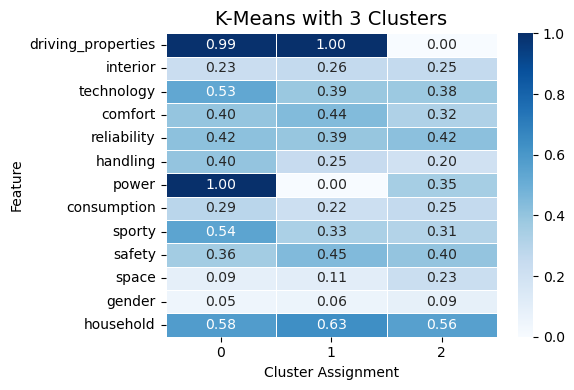

In [11]:

# Visualize the feature means with a heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(
    cluster_means_k3,
    cmap="Blues",        # darker = higher mean
    cbar=True,
    linewidths=0.5,
    annot=True,
    fmt=".2f"
)
plt.title("K-Means with 3 Clusters", fontsize=14)
plt.xlabel("Cluster Assignment")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


**Question 5.** Interpret these 3 clusters by answering the following questions.

-   What is the overall size of each cluster?

-   What is the demographic makeup of each cluster?

-   Which vehicle characteristics are the most important or least important to each cluster?

-   How might you market automobiles differently to people in each cluster?

**Answer 5.**

-   *Cluster 0 has 303 customers, Cluster 1 has 246 customers, and Cluster 2 has 244.*

-   All clusters are mostly male, but Cluster 0 has the highest proportion of female customers. Across all clusters, most customers come from households with at least 3 people, and Cluster 1 is the one with the most households of at least 3 people.

-   For:

    -   Cluster 0:

        -   Most important: Power (1.00), Driving properties (0.99), Sporty (0.54), Technology (0.53)

        -   Least important: Space (0.09), Interior (0.23)

    -   cluster 1:

        -   Most important: Driving properties (1.00), Safety (0.45), Comfort (0.44)

        -   Least important: Power (0.00), Space (0.11), Consumption (0.22)

    -   cluster 2:

        -   Most important: Reliability (0.42), Safety (0.40), Technology (0.38), Power (0.35)

        -   Least important: Handling (0.20), Space (0.23), Interior (0.25), Consumption (0.25)

-   For:
    - Cluster 0: Customers in this group value power, driving performance, sportiness, and technology, while giving little importance to space and interior design. Marketing should highlight sporty, high-performance cars with modern features and advanced driving technology.

    - Cluster 1: These buyers prioritize driving properties, safety, and comfort, showing less concern for power or space. Marketing should focus on comfortable and safe vehicles that deliver a smooth, secure driving experience—ideal for families or daily commuters.

    - Cluster 2: Customers here care most about reliability, safety, technology, and moderate power, but place less emphasis on handling, space, or design details. Marketing should emphasize dependable, efficient cars with balanced performance and strong safety features.

## (c) Choosing the Number of Clusters

In part (b), we simply chose $k = 3$ clusters, but we could have chosen any number of clusters $k$. Let's use a scree plot to decide how many clusters to choose. For each $k$, the scree plot shows the total sum of squared distances of all points within the same cluster.

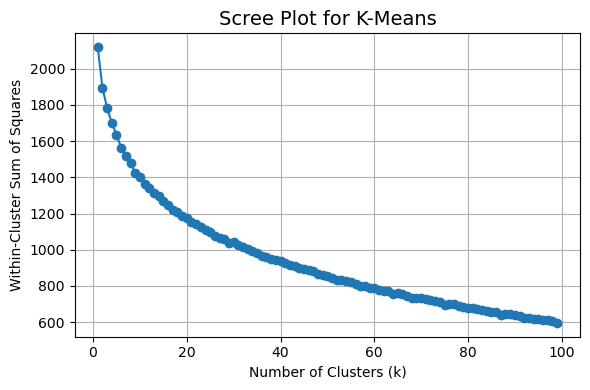

In [12]:

# Range of k values to test
k_values = range(1, 100)

# Compute the total within-cluster sum of squares (inertia) for each k
sum_squared_distances = []
for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        max_iter=100,
        n_init=10,
        random_state=random_state
    )
    kmeans.fit(auto)
    sum_squared_distances.append(kmeans.inertia_)  # inertia = total within-cluster sum of squares

# Store results in a DataFrame
k_results = pd.DataFrame({
    "k": k_values,
    "sum_squared_distances": sum_squared_distances
})

# Plot the scree plot
plt.figure(figsize=(6, 4))
plt.plot(k_results["k"], k_results["sum_squared_distances"], marker="o", linestyle="-")
plt.title("Scree Plot for K-Means", fontsize=14)
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Within-Cluster Sum of Squares")
plt.grid(True)
plt.tight_layout()
plt.show()




**Question 6.** Discuss the trade-offs between choosing a large $k$ and a small $k$. Which value of $k$ would you choose given the above scree plot?


**Answer 6.** *A small value of k leads to cluster which aren't very good and contain people who are very dissimilar. For instance, in the extreme case where k=1, there is only one cluster which contains all the dataset. A number of clusters which is too high is harder to interpret and less informative. In the extreme case where k=n (number of samples in the dataset), each customer is a cluster for instance. On the contrary, an intermediate value for k leads to moderate number of clusters which are easier to interpret and contain similar people. Based on the scree plot, I would choose 3 clusters.*

## (d) Comparing 3 and 10 Clusters

Let's try running k-means with 10 clusters and plotting the same visualization.

In [13]:
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

random_state = 15071

### YOUR CODE HERE ###

# Run K-Means with 10 clusters, 100 maximum iterations, 10 random initial starts, and the fixed random state
kmeans_10 = KMeans(
    n_clusters=10,
    max_iter=100,
    n_init=10,
    random_state=random_state
)

# Fit the model and assign each customer to a cluster
kmeans_10.fit(auto)

### END OF YOUR CODE ###

# Create a version of the data with cluster labels
auto_k10 = auto.copy()
auto_k10["km_10"] = kmeans_10.labels_

# Show the size (number of customers) in each cluster
km_10_sizes = auto_k10["km_10"].value_counts().sort_index()
km_10_sizes

km_10
0    85
1    92
2    97
3    98
4    74
5    72
6    53
7    72
8    80
9    70
Name: count, dtype: int64

In [14]:
cluster_means_k10 = (
    auto_k10
    .groupby("km_10")
    .mean()
    .T   # transpose so features are rows
)

cluster_means_k10

km_10,0,1,2,3,4,5,6,7,8,9
driving_properties,0.717647,0.923913,0.783505,0.867347,0.810811,0.527778,0.943396,0.652778,0.4375,0.142857
interior,0.647059,0.173913,0.123711,0.183673,0.054054,0.250000,0.698113,0.097222,0.1500,0.228571
technology,0.247059,1.000000,0.134021,0.000000,0.378378,0.847222,0.867925,0.972222,0.1750,0.042857
comfort,0.988235,0.217391,0.288660,0.346939,0.486486,0.416667,0.811321,0.347222,0.0625,0.042857
reliability,0.117647,0.086957,0.814433,0.132653,1.000000,0.819444,0.698113,0.083333,0.3625,0.142857
handling,0.082353,0.391304,0.257732,0.346939,0.256757,0.125000,0.811321,0.138889,0.3750,0.257143
power,0.058824,0.858696,0.103093,0.887755,0.986486,0.041667,0.962264,0.527778,0.3500,0.200000
consumption,0.282353,0.195652,0.010309,0.081633,0.189189,0.194444,0.660377,0.125000,1.0000,0.000000
sporty,0.188235,0.521739,0.494845,0.857143,0.405405,0.125000,0.792453,0.250000,0.2750,0.085714
safety,0.329412,0.000000,0.773196,0.173469,0.324324,0.263889,0.830189,1.000000,0.2750,0.228571


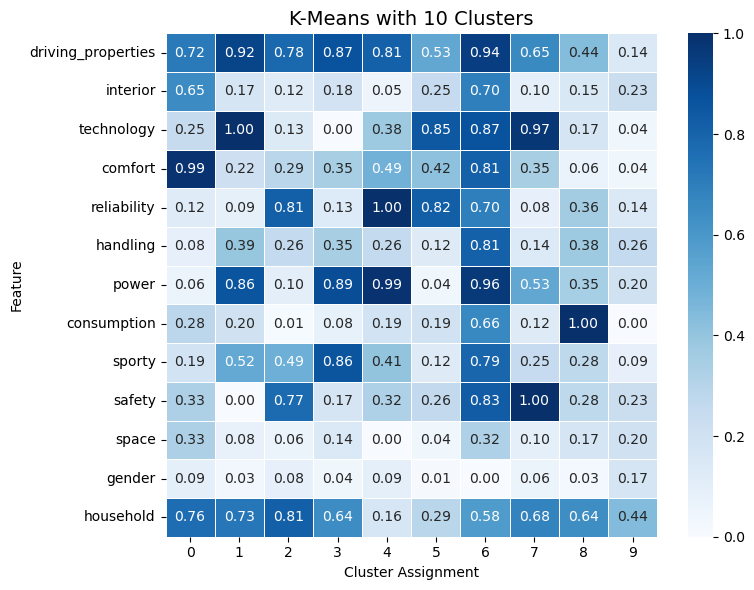

In [15]:


# Visualize the feature means with a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    cluster_means_k10,
    cmap="Blues",        # darker = higher mean
    cbar=True,
    linewidths=0.5,
    annot=True,
    fmt=".2f"
)
plt.title("K-Means with 10 Clusters", fontsize=14)
plt.xlabel("Cluster Assignment")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

**Question 7**. How might you interpret clusters 6 and 9 above?

**Answer 7.**
- Cluster 6 scores high on nearly all driving-related and technology-oriented attributes, such as Power, Driving properties, Comfort, Safety, Technology, and Handling. These customers appear to be performance-focused, tech-savvy drivers who value cars that feel powerful, handle well, and are packed with modern features.
- Cluster 9 shows very low importance across nearly all attributes. This group places little emphasis on performance, technology, or comfort, suggesting they may view cars as a basic necessity rather than a lifestyle choice. They are likely price-sensitive, practical consumers looking for simple transportation.

Let's examine how these 10 clusters relate to the original 3 clusters. Let's use the method `pd.crosstab`, which counts the number of data points that was assigned to a particular cluster in `kmeans_3` and `kmeans_10`. For example, there are 69 customers assigned to cluster 1 in `kmeans_3` and cluster 0 in`kmeans_10`.

In [16]:
# Create a DataFrame containing both cluster assignments
cluster_compare = pd.DataFrame({
    "km_3": kmeans_3.labels_,
    "km_10": kmeans_10.labels_
})

# Generate a cross-tabulation
cluster_table = pd.crosstab(cluster_compare["km_3"], cluster_compare["km_10"])

cluster_table



km_10,0,1,2,3,4,5,6,7,8,9
km_3,,,,,,,,,,
0,3,72,8,76,60,0,48,25,11,0
1,58,13,68,10,1,38,2,22,24,10
2,24,7,21,12,13,34,3,25,45,60


We can visualize how the 3 clusters differ from the 10 clusters with a heatmap.

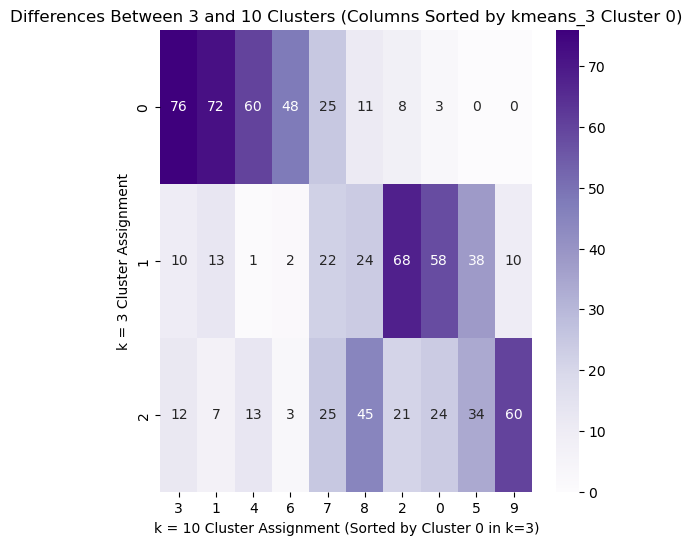

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# Sort columns (x-axis) based on their counts in cluster_0 (row 0 of km_3)
col_order = cluster_table.loc[0].sort_values(ascending=False).index

# Apply this new column order
cluster_table_sorted = cluster_table[col_order]

plt.figure(figsize=(6, 6))
sns.heatmap(cluster_table_sorted, cmap="Purples", annot=True, fmt="d")
plt.title("Differences Between 3 and 10 Clusters (Columns Sorted by kmeans_3 Cluster 0)")
plt.xlabel("k = 10 Cluster Assignment (Sorted by Cluster 0 in k=3)")
plt.ylabel("k = 3 Cluster Assignment")
plt.show()


**Question 8.** Discuss the relationship between the cluster assignments from `kmeans_10` and `kmeans_3`. As a concrete example, provide an interpretation of clusters 1, 3, 4 and 6 in `kmeans_10` and how they relate to cluster 0 in `kmeans_3`.

**Answer 8.**

Clusters 1, 3, 4, and 6 in kmeans_10 all stem mainly from cluster 0 in kmeans_3, which represents performance- and technology-oriented drivers. They share a common focus on **power** and **driving properties**, but **further segment** this broader group into more specific **subtypes**.

- Cluster 1 highly focues **technology** (1.00), capturing drivers attracted to cutting-edge features and strong performance.

- Cluster 3 strongly emphasizes on **sporty** (0.83), prioritizing driving excitement.

- Cluster 4 highly values **reliability** (1.00), suggesting customers who want both power and dependability.

- Cluster 6 values nearly all characteristics, reflecting **balanced**, high-end drivers who appreciate performance without compromising comfort or safety.

Overall, these subclusters refine the broader performance-driven group (cluster 0) into distinct profiles — ranging from tech-focused to sport-oriented to comfort-conscious drivers.

## (e) Hierarchical Clustering

Now, let's try hierarchical cluster instead of k-means. First, let's build a dendrogram using the `pdist` and `linkage` functions from `scipy`. We use `ward` method to define how distances between clusters are calculated.

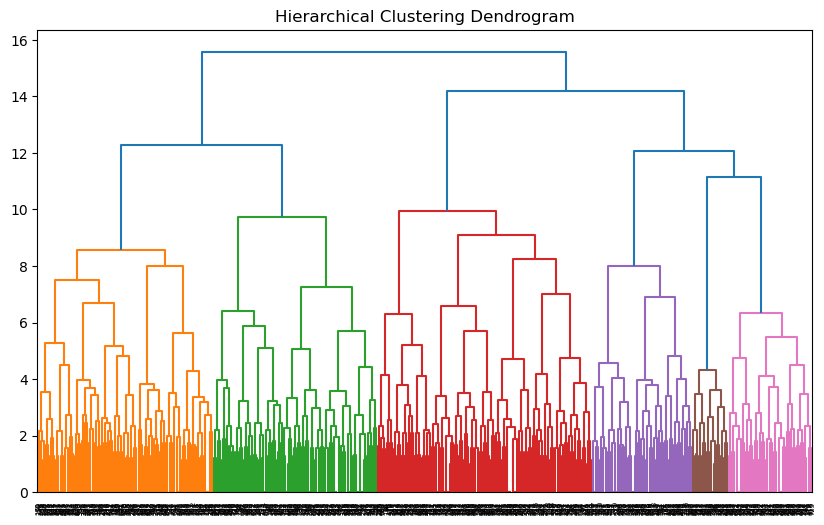

In [18]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist
import matplotlib.pyplot as plt


# Compute pairwise distances between observations
dist_matrix = pdist(auto, metric='euclidean')

# Perform hierarchical clustering using Ward’s method
hclust_tree = linkage(dist_matrix, method='ward')

# Plot the dendrogram
plt.figure(figsize=(10, 6))
dendrogram(hclust_tree)
plt.xlabel(None)
plt.ylabel(None)
plt.title("Hierarchical Clustering Dendrogram")
plt.show()

Let's cut the dendrogram at a certain height to give rise to 3 clusters.

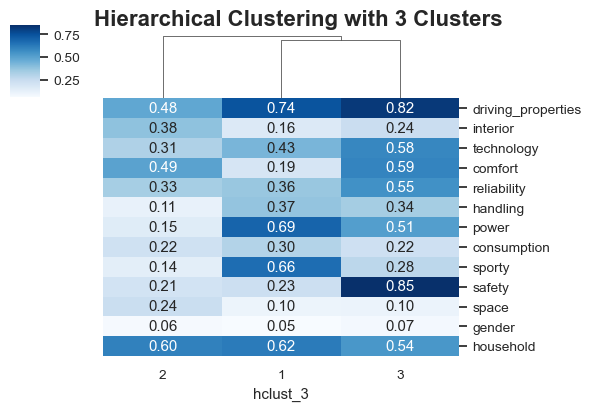

In [19]:
### YOUR CODE HERE ###

# Cut the dendrogram into 3 clusters
hclust_3 = fcluster(hclust_tree, t=3, criterion='maxclust')

### END OF YOUR CODE ###

# Add cluster labels to the dataframe
auto_hclust = auto.copy()
auto_hclust['hclust_3'] = hclust_3

# Compute the mean of each feature for each cluster
cluster_means = auto_hclust.groupby('hclust_3').mean().T

sns.set_theme(style="white", font_scale=0.9)

# Create clustermap
g = sns.clustermap(cluster_means,
                   cmap="Blues",
                   method="ward",
                   metric="euclidean",
                   figsize=(6, 4),
                   col_cluster=True,
                   row_cluster=False,
                   annot=True,
                   fmt=".2f")

# Add title and adjust layout
g.fig.suptitle("Hierarchical Clustering with 3 Clusters",
               fontsize=16, fontweight="bold", y=1.02)
plt.show()

In [20]:
# Count number of observations in each cluster
pd.Series(hclust_3).value_counts().sort_index()

1    348
2    219
3    226
Name: count, dtype: int64

**Question 9.** Provide an interpretation of these 3 clusters. Are they similar to those from K-Means in `kmeans_3`? If we were to use hierarchical clustering with 2 clusters (i.e., `fcluster(hclust_tree, t=2, criterion='maxclust')`), what would those two clusters be?

**Answer 9.**
- Cluster 3 focuses on **driving propoerties**, **sporty**, and **power**, less on space (similar to Cluster 0 in k-means).
- Cluster 1 focues on **safety, comfort, driving properties, and reliability** (similar to Cluster 1 in k-means)
- Cluster 2 values **driving properties, technology, comfort, power, and safety**, representing a balanced group. It resembles Cluster 2 in K-Means but differs slightly, placing greater weight on driving properties and technology.

 If use hierarchical clustering with 2 clusters, cluster 1 and 3 would be merged into 1 cluster.

Similar to before, let's also try cutting the tree to generate 10 clusters and compare it to 3 clusters.

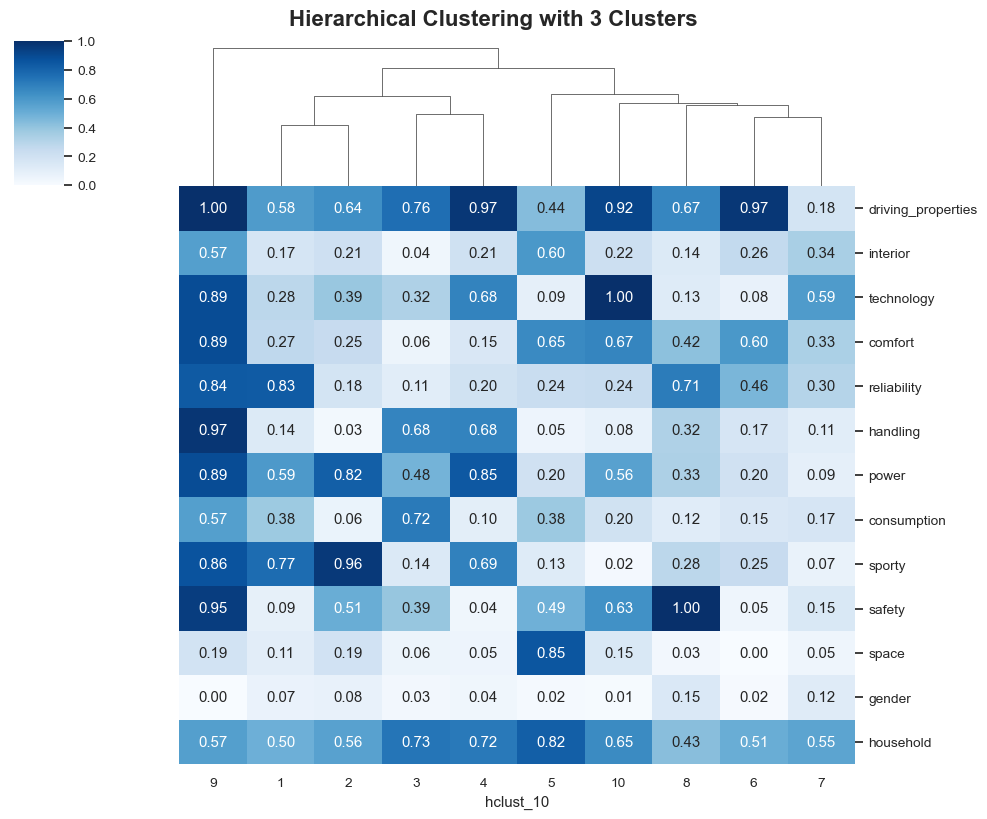

In [21]:
### YOUR CODE HERE ###

# Cut the dendrogram into 3 clusters
hclust_10 = fcluster(hclust_tree, t=10, criterion='maxclust')

### END OF YOUR CODE ###

# Add cluster labels to the dataframe
auto_hclust = auto.copy()
auto_hclust['hclust_10'] = hclust_10

# Compute the mean of each feature for each cluster
cluster_means = auto_hclust.groupby('hclust_10').mean().T

# Create clustermap
g = sns.clustermap(cluster_means,
                   cmap="Blues",
                   method="ward",
                   metric="euclidean",
                   figsize=(10, 8),
                   col_cluster=True,
                   row_cluster=False,
                   annot=True,
                   fmt=".2f")

# Add title and adjust layout
g.fig.suptitle("Hierarchical Clustering with 3 Clusters",
               fontsize=16, fontweight="bold", y=1.02)
plt.show()

Here is the table showing the relationship between clusters in `hclust_3` and `hclust_10`.

In [22]:
cluster_compare = pd.DataFrame({
    "hclust_3": hclust_3,
    "hclust_10": hclust_10
})

# Generate a contingency table
cluster_table = pd.crosstab(cluster_compare["hclust_3"], cluster_compare["hclust_10"])
cluster_table

hclust_10,1,2,3,4,5,6,7,8,9,10
hclust_3,,,,,,,,,,
1,103,77,71,97,0,0,0,0,0,0
2,0,0,0,0,55,65,99,0,0,0
3,0,0,0,0,0,0,0,103,37,86


**Question 10.** Using the table above, discuss the hierarchical structure of these 10 clusters. How does this table compare to the one from question 8 for K-Means?


Here, we see that the 3 clusters we obtain at the previous question are further divided into smaller clusters. On the contrary, samples from two different clusters in kmeans_3 could end up the same cluster in kmeans_10.